# Chapter 40 — Classification: Choosing Among Several Options

## Learning goals

Earlier models often returned one number, but a language model must compare many possible next tokens.

This chapter introduces single-label multiclass classification: choosing one answer from a fixed set of options.

By the end of this chapter, you should be able to:

1. Explain a class and a multiclass classification problem.
2. Explain why next-token prediction is classification at every token position.
3. Store one raw score per class.
4. Keep class labels, class IDs, and scores aligned.
5. Find the predicted class with an argmax operation.
6. Distinguish the predicted class from the correct class.
7. Explain why raw scores are not probabilities.
8. Handle tied highest scores explicitly.
9. Plot class scores as a bar chart.
10. Connect vocabulary size to language-model output size.

## The basic idea

A single-label multiclass classifier chooses exactly one class from several mutually exclusive options.

For an input described as `red fruit`, the possible classes might be:

```text
apple
banana
carrot
```

The model produces one score for each option rather than directly emitting the word `apple`.

The class with the highest score is the prediction.

## Language modeling is repeated classification

Given the context `the cat sat on the`, a model scores every token in its vocabulary as a possible continuation.

One token position is one multiclass classification problem:

```text
choose one next token from the vocabulary
```

A vocabulary of 50 tokens requires 50 output scores at that position, while a vocabulary of 50,000 tokens requires 50,000 scores.

Generation repeats this decision after appending each selected token.

## Terms used in this chapter

- A **class** is one possible answer.
- A **class ID** is the integer position assigned to a class.
- A **class score** is a raw model output for one class.
- A **logit** is the usual machine-learning name for a raw class score.
- The **predicted class** is selected from the highest score.
- The **correct class** or **target class** comes from the dataset.
- A **vocabulary** is the set of tokens available to a language model.
- A **probability distribution** contains values from 0 to 1 that sum to 1.
- **Argmax** returns the index of a largest value.

Raw logits are not probabilities.

## Represent a tiny classification problem

The class list defines the meaning of every score position.

Class labels should be unique because each position needs one unambiguous meaning.

In [1]:
input_text = "red fruit"
possible_classes = ["apple", "banana", "carrot"]
correct_class = "apple"

print("Input:", input_text)
print("Possible classes:", possible_classes)
print("Correct class:", correct_class)

assert len(possible_classes) == len(set(possible_classes))
assert correct_class in possible_classes

Input: red fruit
Possible classes: ['apple', 'banana', 'carrot']
Correct class: apple


## Store one score per class

Lists match the representation used by model outputs: score index `i` belongs to class index `i`.

In [2]:
class_scores = [2.5, 0.8, -1.2]

if len(possible_classes) != len(class_scores):
    raise ValueError("There must be exactly one score per class.")

print("class ID | class name | raw score")
print("-" * 35)
for class_id, (class_name, score) in enumerate(
    zip(possible_classes, class_scores, strict=True)
):
    print(f"{class_id:>8} | {class_name:>10} | {score:>9.2f}")

class ID | class name | raw score
-----------------------------------
       0 |      apple |      2.50
       1 |     banana |      0.80
       2 |     carrot |     -1.20


## Find the argmax

The predicted class ID is the index of the highest score.

This implementation returns the first highest index if several scores tie, making its tie rule explicit and deterministic.

In [3]:
def find_index_of_highest_score(scores: list[float]) -> int:
    if not scores:
        raise ValueError("scores must not be empty.")

    highest_index = 0

    for score_index in range(1, len(scores)):
        if scores[score_index] > scores[highest_index]:
            highest_index = score_index

    return highest_index


predicted_class_id = find_index_of_highest_score(class_scores)
predicted_class = possible_classes[predicted_class_id]
correct_class_id = possible_classes.index(correct_class)

print("Predicted class ID:", predicted_class_id)
print("Predicted class:", predicted_class)
print("Correct class ID:", correct_class_id)
print("Correct class:", correct_class)
print("Prediction correct?", predicted_class_id == correct_class_id)

assert predicted_class == "apple"
assert predicted_class_id == correct_class_id

Predicted class ID: 0
Predicted class: apple
Correct class ID: 0
Correct class: apple
Prediction correct? True


## Predicted and correct are different roles

The predicted class comes from model scores.

The correct class comes from labeled data.

Training is needed when those two values disagree.

In [4]:
wrong_class_scores = [1.1, 2.3, -0.4]
wrong_predicted_class_id = find_index_of_highest_score(wrong_class_scores)
wrong_predicted_class = possible_classes[wrong_predicted_class_id]

print("Wrong-example scores:", wrong_class_scores)
print("Predicted class:", wrong_predicted_class)
print("Correct class:", correct_class)
print("Prediction correct?", wrong_predicted_class_id == correct_class_id)

assert wrong_predicted_class == "banana"
assert wrong_predicted_class_id != correct_class_id

Wrong-example scores: [1.1, 2.3, -0.4]
Predicted class: banana
Correct class: apple
Prediction correct? False


## Print a reusable classification report

Validation prevents a shifted or incomplete score list from silently changing the meaning of the output.

In [5]:
def validate_classification_example(
    class_names: list[str],
    scores: list[float],
    target_class_id: int,
) -> None:
    if not class_names:
        raise ValueError("class_names must not be empty.")

    if len(class_names) != len(set(class_names)):
        raise ValueError("class_names must be unique.")

    if len(class_names) != len(scores):
        raise ValueError("There must be exactly one score per class.")

    if not 0 <= target_class_id < len(class_names):
        raise ValueError("target_class_id is out of range.")


def print_classification_report(
    example_text: str,
    class_names: list[str],
    scores: list[float],
    target_class_id: int,
) -> None:
    validate_classification_example(class_names, scores, target_class_id)
    report_predicted_id = find_index_of_highest_score(scores)

    print("Input:", example_text)
    print("class ID | class name | score | target? | predicted?")
    print("-" * 58)

    for report_class_id, (class_name, score) in enumerate(
        zip(class_names, scores, strict=True)
    ):
        print(
            f"{report_class_id:>8} | {class_name:>10} | {score:>5.2f} | "
            f"{str(report_class_id == target_class_id):>7} | "
            f"{str(report_class_id == report_predicted_id):>10}"
        )

    print("Predicted:", class_names[report_predicted_id])
    print("Correct:", class_names[target_class_id])
    print("Prediction correct?", report_predicted_id == target_class_id)


print_classification_report(
    input_text,
    possible_classes,
    class_scores,
    correct_class_id,
)

Input: red fruit
class ID | class name | score | target? | predicted?
----------------------------------------------------------
       0 |      apple |  2.50 |    True |       True
       1 |     banana |  0.80 |   False |      False
       2 |     carrot | -1.20 |   False |      False
Predicted: apple
Correct: apple
Prediction correct? True


## Plot raw class scores

A bar chart makes the winning class and the competing scores visible.

The highlighted bar is both the prediction and target in this example.

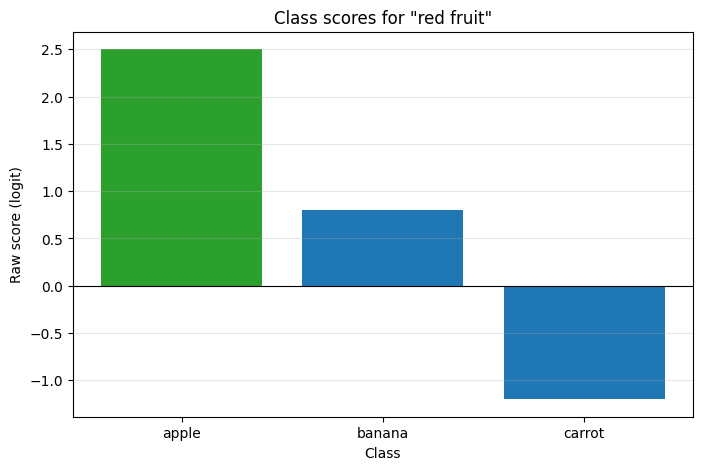

In [6]:
import matplotlib.pyplot as plt

fruit_bar_colors = [
    "tab:green" if class_id == predicted_class_id else "tab:blue"
    for class_id in range(len(possible_classes))
]

plt.figure(figsize=(8, 5))
plt.bar(possible_classes, class_scores, color=fruit_bar_colors)
plt.axhline(0.0, color="black", linewidth=0.8)
plt.xlabel("Class")
plt.ylabel("Raw score (logit)")
plt.title('Class scores for "red fruit"')
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Raw scores are not probabilities

Probabilities must be between 0 and 1 and must sum to 1.

Logits can be any real numbers, including negative numbers and numbers greater than 1.

In [7]:
raw_score_sum = sum(class_scores)
all_raw_scores_in_probability_range = all(0.0 <= score <= 1.0 for score in class_scores)
raw_scores_sum_to_one = abs(raw_score_sum - 1.0) < 1e-12

print("Raw scores:", class_scores)
print("Raw score sum:", raw_score_sum)
print("All scores between 0 and 1?", all_raw_scores_in_probability_range)
print("Scores sum to 1?", raw_scores_sum_to_one)

assert not all_raw_scores_in_probability_range
assert not raw_scores_sum_to_one

Raw scores: [2.5, 0.8, -1.2]
Raw score sum: 2.1
All scores between 0 and 1? False
Scores sum to 1? False


## The decision uses relative order

Adding the same constant to every logit or multiplying every logit by a positive number preserves the argmax.

That does not make scale irrelevant: softmax probabilities and training loss can change even when the winning class stays the same.

The next chapter will make that distinction visible.

In [8]:
shifted_scores = [score + 100.0 for score in class_scores]
positive_scaled_scores = [score * 10.0 for score in class_scores]

original_winner = find_index_of_highest_score(class_scores)
shifted_winner = find_index_of_highest_score(shifted_scores)
scaled_winner = find_index_of_highest_score(positive_scaled_scores)

print("Original scores:", class_scores)
print("Shifted scores:", shifted_scores)
print("Positive-scaled scores:", positive_scaled_scores)
print("Winning class IDs:", original_winner, shifted_winner, scaled_winner)

assert original_winner == shifted_winner == scaled_winner

Original scores: [2.5, 0.8, -1.2]
Shifted scores: [102.5, 100.8, 98.8]
Positive-scaled scores: [25.0, 8.0, -12.0]
Winning class IDs: 0 0 0


## All logits may be negative

Argmax asks which score is largest, not whether it is positive.

In [9]:
negative_class_scores = [-0.2, -1.5, -3.0]
negative_score_winner_id = find_index_of_highest_score(negative_class_scores)

print("All-negative scores:", negative_class_scores)
print("Predicted class:", possible_classes[negative_score_winner_id])

assert negative_score_winner_id == 0

All-negative scores: [-0.2, -1.5, -3.0]
Predicted class: apple


## Tied scores need a rule

Mathematically, a tie means more than one class is an argmax.

Our helper chooses the first tied class, but a report can expose all tied winners instead of hiding the ambiguity.

In [10]:
def find_all_highest_score_indices(scores: list[float]) -> list[int]:
    if not scores:
        raise ValueError("scores must not be empty.")

    highest_score = max(scores)
    return [index for index, score in enumerate(scores) if score == highest_score]


tied_scores = [1.7, 1.7, -0.3]
tied_winner_ids = find_all_highest_score_indices(tied_scores)
first_tied_winner_id = find_index_of_highest_score(tied_scores)

print("Tied scores:", tied_scores)
print("All highest-score class IDs:", tied_winner_ids)
print("Deterministic first winner:", first_tied_winner_id)

assert tied_winner_ids == [0, 1]
assert first_tied_winner_id == 0

Tied scores: [1.7, 1.7, -0.3]
All highest-score class IDs: [0, 1]
Deterministic first winner: 0


## Class IDs mirror token IDs

Human-readable labels help us inspect examples, while models usually use integer IDs.

The score at index `i` belongs to class ID `i`, just as a language model's score at vocabulary index `i` belongs to token ID `i`.

In [11]:
class_to_id = {
    class_name: class_id for class_id, class_name in enumerate(possible_classes)
}
id_to_class = list(possible_classes)

print("Class to ID:", class_to_id)
print("ID to class:", id_to_class)
print("Correct class ID:", class_to_id[correct_class])

assert id_to_class[class_to_id["banana"]] == "banana"

Class to ID: {'apple': 0, 'banana': 1, 'carrot': 2}
ID to class: ['apple', 'banana', 'carrot']
Correct class ID: 0


## A tiny next-token classification problem

Replace fruit labels with vocabulary tokens and keep the same score-and-argmax procedure.

In [12]:
context_text = "the cat sat on the"
vocabulary_tokens = ["mat", "rug", "dog", "apple", "."]
next_token_scores = [3.2, 2.1, -0.5, -2.0, 0.3]
correct_next_token_id = vocabulary_tokens.index("mat")
predicted_next_token_id = find_index_of_highest_score(next_token_scores)

print("Context:", context_text)
print("Vocabulary:", vocabulary_tokens)
print("Next-token logits:", next_token_scores)
print("Predicted token:", vocabulary_tokens[predicted_next_token_id])
print("Correct token:", vocabulary_tokens[correct_next_token_id])

assert predicted_next_token_id == correct_next_token_id

Context: the cat sat on the
Vocabulary: ['mat', 'rug', 'dog', 'apple', '.']
Next-token logits: [3.2, 2.1, -0.5, -2.0, 0.3]
Predicted token: mat
Correct token: mat


## Plot next-token logits

The model scores every vocabulary token even though the dataset supplies only one correct next token.

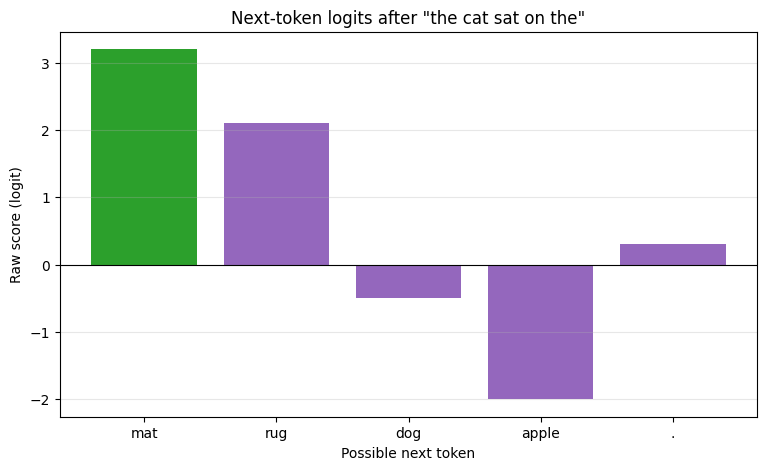

In [13]:
next_token_colors = [
    "tab:green" if token_id == predicted_next_token_id else "tab:purple"
    for token_id in range(len(vocabulary_tokens))
]

plt.figure(figsize=(9, 5))
plt.bar(vocabulary_tokens, next_token_scores, color=next_token_colors)
plt.axhline(0.0, color="black", linewidth=0.8)
plt.xlabel("Possible next token")
plt.ylabel("Raw score (logit)")
plt.title(f'Next-token logits after "{context_text}"')
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## Vocabulary size determines output size

At one position, there must be exactly one score per vocabulary token.

The score vector shape is therefore `[vocabulary_size]`.

In [14]:
fake_vocabulary = [f"token_{token_id}" for token_id in range(50)]
fake_token_scores = [-2.0 + 0.1 * token_id for token_id in range(50)]

print("Vocabulary size:", len(fake_vocabulary))
print("Score count:", len(fake_token_scores))
print("One-position score shape:", [len(fake_token_scores)])
print("First three pairs:")
for token, score in zip(fake_vocabulary[:3], fake_token_scores[:3], strict=True):
    print(" ", token, "→", score)

assert len(fake_vocabulary) == len(fake_token_scores) == 50

Vocabulary size: 50
Score count: 50
One-position score shape: [50]
First three pairs:
  token_0 → -2.0
  token_1 → -1.9
  token_2 → -1.8


## From one position to a sequence

This chapter focuses on one token position, whose output shape is `[vocabulary_size]`.

Computing scores at every position in a sequence adds a position dimension:

```text
[sequence_length, vocabulary_size]
```

Adding a batch dimension later produces `[batch_size, sequence_length, vocabulary_size]`.

These are shape previews; later chapters will build the corresponding tensor code.

## A classifier scores every option

The model cannot compare classes if it outputs only the target's score.

For the fruit example it scores apple, banana, and carrot, and for language modeling it scores every vocabulary token.

Training will eventually encourage the target logit to outrank competing logits.

## Output units correspond to classes

A neural-network classifier with three classes ends with three output units.

For a vocabulary of size `V`, a language model's final projection produces `V` logits at each position.

No ReLU should be applied merely to make these final logits positive because logits are allowed to be any real numbers.

## Classification and generation

Classification describes one next-token decision.

Autoregressive generation repeats the process:

1. Produce logits for the next token.
2. Select or sample one token.
3. Append it to the context.
4. Run the model again.

Later chapters will replace simple argmax selection with probabilities and sampling strategies.

## A clean classification pipeline

This compact example validates the class-score alignment, finds the predicted class ID, reports correctness, and plots all logits.

Input: red fruit
Classes: ['apple', 'banana', 'carrot']
Logits: [2.5, 0.8, -1.2]
Predicted class: apple
Correct class: apple
Prediction correct? True


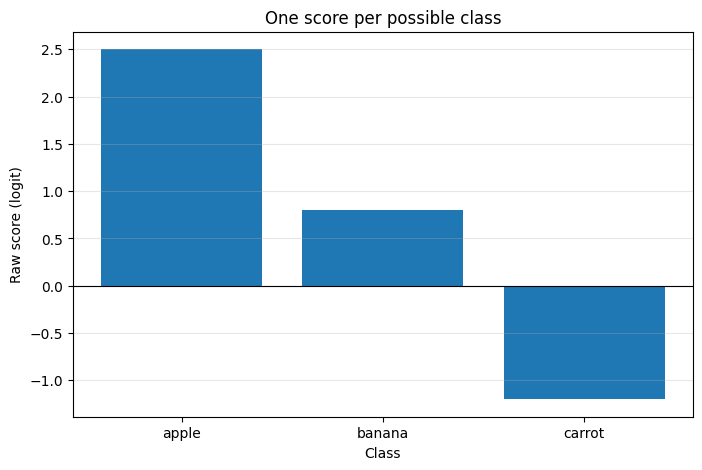

In [15]:
pipeline_input = "red fruit"
pipeline_classes = ["apple", "banana", "carrot"]
pipeline_scores = [2.5, 0.8, -1.2]
pipeline_target_id = 0

validate_classification_example(
    pipeline_classes,
    pipeline_scores,
    pipeline_target_id,
)
pipeline_prediction_id = find_index_of_highest_score(pipeline_scores)

print("Input:", pipeline_input)
print("Classes:", pipeline_classes)
print("Logits:", pipeline_scores)
print("Predicted class:", pipeline_classes[pipeline_prediction_id])
print("Correct class:", pipeline_classes[pipeline_target_id])
print("Prediction correct?", pipeline_prediction_id == pipeline_target_id)

plt.figure(figsize=(8, 5))
plt.bar(pipeline_classes, pipeline_scores)
plt.axhline(0.0, color="black", linewidth=0.8)
plt.xlabel("Class")
plt.ylabel("Raw score (logit)")
plt.title("One score per possible class")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## What not to do

- Do not treat raw logits as probabilities.
- Do not output only one score for a multiclass problem.
- Do not lose the alignment between class IDs and score positions.
- Do not confuse the model's predicted class with the dataset's target class.
- Do not hide tied highest scores without choosing or reporting a tie rule.
- Do not assume score scale is irrelevant merely because positive scaling preserves argmax.
- Do not forget that language modeling performs this classification at every token position.

## Gotchas

### Raw logits can be any real numbers

They may be negative, zero, or greater than 1.

### The highest logit determines argmax prediction

The target does not necessarily have the highest score before training.

### Ties are possible

An implementation needs a deterministic rule or an explicit representation of all tied winners.

### Class order is part of the representation

Score index `i` has meaning only through the class or token assigned to index `i`.

### Output width equals class count

A vocabulary of size `V` requires `V` logits at each token position.

## Takeaways

Single-label multiclass classification chooses one option from a fixed set of classes.

The model emits one raw logit per class, and argmax finds a highest-scoring class ID.

Raw logits are not probabilities because they are unrestricted real numbers and need not sum to 1.

Language modeling applies the same idea at every token position, using vocabulary tokens as classes.

For one position:

```text
number of output logits = vocabulary size
```

## What comes next

The next chapter introduces softmax.

Softmax transforms raw logits into a probability distribution while preserving their ordering, allowing us to discuss both the winning class and the probability assigned to every option.